In [1]:
# Homework9
# 2.1 Collect the Data
# 2.1.2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# 2.1.3
df = pd.read_csv("noisy_curvefit_data.csv")

In [3]:
# 2.1.4
print(df.shape)
# The dataset has 100 rows and 6 columns
print(df.head())
print(df.tail())
# The column names are x, y_noise_1, y_noise_2, y_noise_3, y_noise_4, and y_noise_5

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


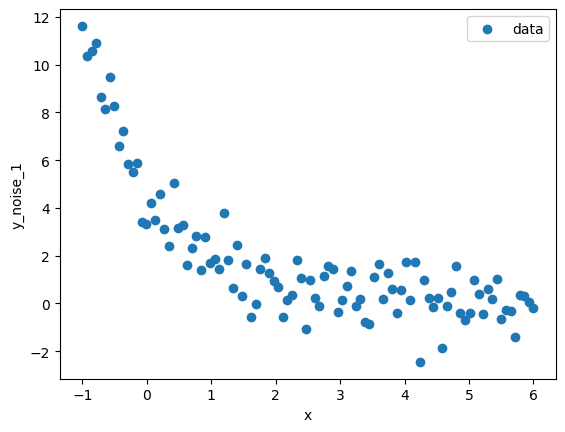

In [4]:
# 2.1.5
plt.scatter(df["x"], df["y_noise_1"], label="data")
plt.xlabel("x")
plt.ylabel("y_noise_1")
plt.legend()
plt.show()

In [5]:
# 2.2 Fit the Data
# 2.2.1
def model(x, A, k):
    return A * np.exp(-k * x)

In [6]:
# 2.2.2
x = df["x"]
y_noise_1 = df["y_noise_1"]
p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

In [7]:
# 2.2.3
A_fit, k_fit = popt

In [8]:
# 2.2.4
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [9]:
# 2.2.5
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

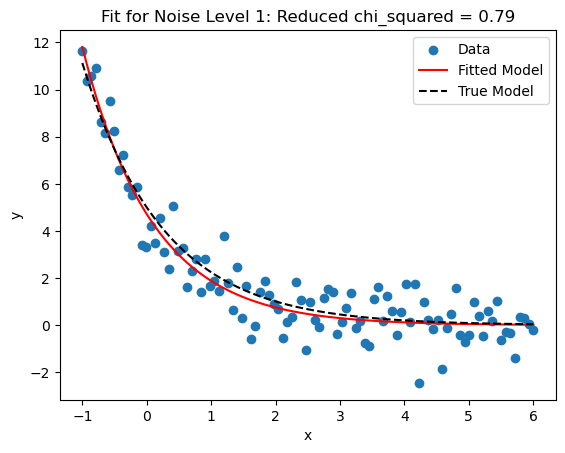

In [10]:
# 2.2.6
plt.scatter(x, y_noise_1, label="Data")
plt.plot(x, model(x, A_fit, k_fit), label="Fitted Model", color="red")
plt.plot(x, model(x, 5, 0.8), label="True Model", color="black", linestyle="--")
plt.title(f"Fit for Noise Level 1: Reduced chi_squared = {chi2_reduced:.2f}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [11]:
# 2.3 Compare the Different Noise Levels
# 2.3.1
def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    return A_fit, k_fit, chi2_reduced

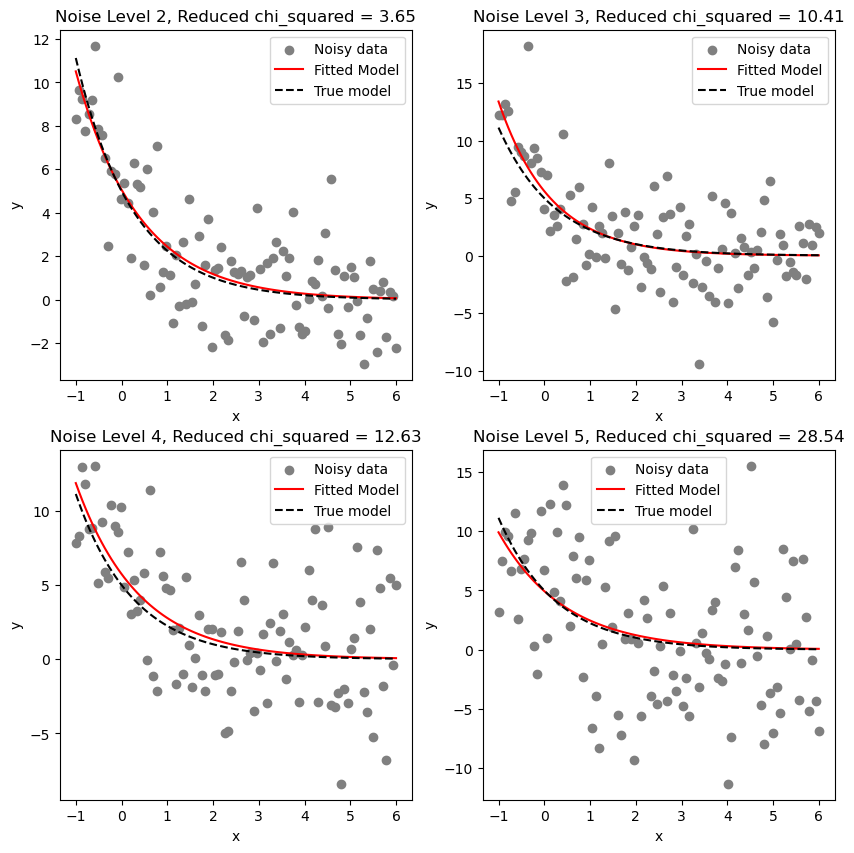

In [12]:
# 2.3.2 - 2.3.3, and 2.4
fig, axes = plt.subplots(2, 2, figsize = (10, 10))

row = 0
column = 0
y_noise_columns = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]
for i, column_name in enumerate(y_noise_columns):
    ax = axes[row, column]
    y = df[column_name].values
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    ax.scatter(x, y, color="gray", label="Noisy data")
    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted Model")
    ax.plot(x, model(x, 5, 0.8), color="black", linestyle="--", label="True model")
    noise_level = i + 2
    ax.set_title(f"Noise Level {noise_level}, Reduced chi_squared = {chi2_reduced:.2f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()
    column += 1
    if column == 2:
        column = 0
        row += 1
plt.show()

In [13]:
# 2.3.4
# The red line shifts relative to the black line as the noise level increases, because as the data deviates more from the true model the parameters for the red line keep shifting.
# The reduced chi-squared increases as the noise level increases, because the data is getting less and less accurate as compared to the true model

In [14]:
# 2.4 Save Your Results
noise_columns = ["y_noise_1", "y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]
noise_levels = [1, 2, 3, 4, 5]
A_fits = []
k_fits = []
chi2_values = []

for column in noise_columns:
    y = df[column].values
    A_fit, k_fit, chi2_reduced = fit_model(x, y)
    A_fits.append(A_fit)
    k_fits.append(k_fit)
    chi2_values.append(chi2_reduced)

noisy_parameters_df = pd.DataFrame({"Noise Level": noise_levels, "A fit": A_fits, "k_fit": k_fits, "Reduced chi_squared": chi2_values})

noisy_parameters_df.to_csv("noisy_parameters.csv", index=False)